# HOMEWORK – BÀI 7
## Bài 1 – Titanic Dataset
- Logistic Regression dự đoán hành khách sống sót.
- Linear Regression kết hợp ngưỡng 0.5 để đối chiếu.
- Đánh giá bằng Accuracy, Precision, Recall, F1-score và Confusion Matrix.

## Bài 2 – Dry Bean Dataset
- Đọc dữ liệu đã preprocessing hoặc tự preprocessing từ file Excel.
- Xây dựng Logistic Regression và KNN.
- Đánh giá, so sánh và kết luận.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20

# BÀI 1 – TITANIC DATASET

Biến mục tiêu `Survived`:

- `0`: không sống sót.
- `1`: sống sót.

Hai mô hình sử dụng cùng feature, cùng tập train và cùng tập test để việc so sánh công bằng.

In [2]:
TITANIC_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(TITANIC_URL)

print("Kích thước Titanic Dataset:", titanic_df.shape)
display(titanic_df.head())

Kích thước Titanic Dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


In [3]:
print("THÔNG TIN TITANIC DATASET")
print("=" * 60)
titanic_df.info()

missing_titanic = pd.DataFrame({
    "Missing count": titanic_df.isna().sum(),
    "Missing percent": (titanic_df.isna().mean() * 100).round(2)
})

print("\nMISSING VALUES")
display(missing_titanic)

print("Số dòng trùng:", titanic_df.duplicated().sum())

THÔNG TIN TITANIC DATASET
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

MISSING VALUES


,Missing count,Missing percent
PassengerId,0,0.0000
Survived,0,0.0000
Pclass,0,0.0000
Name,0,0.0000
Sex,0,0.0000
Age,177,19.8700
SibSp,0,0.0000
Parch,0,0.0000
Ticket,0,0.0000
Fare,0,0.0000


Số dòng trùng: 0


,Số hành khách,Tỷ lệ (%)
Không sống sót,549,61.6200
Sống sót,342,38.3800


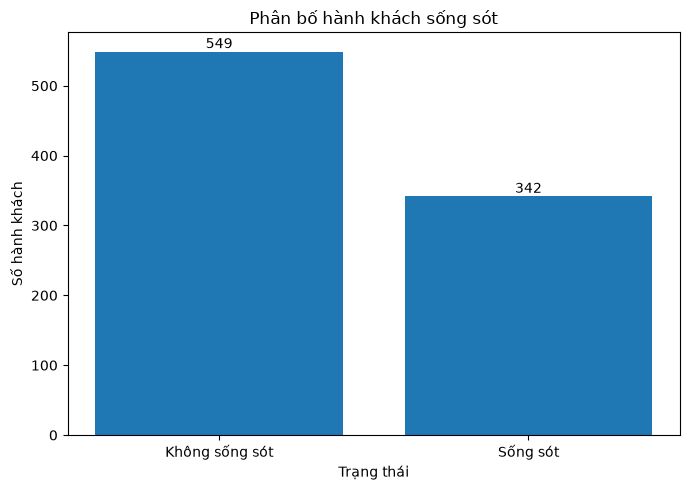

In [4]:
survival_distribution = pd.DataFrame({
    "Số hành khách": titanic_df["Survived"].value_counts().sort_index(),
    "Tỷ lệ (%)": (
        titanic_df["Survived"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

survival_distribution.index = ["Không sống sót", "Sống sót"]
display(survival_distribution)

survival_counts = titanic_df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
bars = plt.bar(["Không sống sót", "Sống sót"], survival_counts.values)
plt.title("Phân bố hành khách sống sót")
plt.xlabel("Trạng thái")
plt.ylabel("Số hành khách")

for bar in bars:
    value = int(bar.get_height())
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Lựa chọn đặc trưng Titanic

Các đặc trưng được sử dụng:

- `Pclass`: hạng vé.
- `Sex`: giới tính.
- `Age`: tuổi.
- `SibSp`: số anh chị em hoặc vợ/chồng đi cùng.
- `Parch`: số cha mẹ hoặc con đi cùng.
- `Fare`: giá vé.
- `Embarked`: cảng lên tàu.

In [5]:
titanic_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X_titanic = titanic_df[titanic_features].copy()
y_titanic = titanic_df["Survived"].copy()

(
    X_train_titanic,
    X_test_titanic,
    y_train_titanic,
    y_test_titanic
) = train_test_split(
    X_titanic,
    y_titanic,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_titanic
)

print("X_train:", X_train_titanic.shape)
print("X_test :", X_test_titanic.shape)
print("y_train:", y_train_titanic.shape)
print("y_test :", y_test_titanic.shape)

X_train: (712, 7)
X_test : (179, 7)
y_train: (712,)
y_test : (179,)


## Tiền xử lý Titanic

- Các biến số được điền missing bằng median và chuẩn hóa bằng `StandardScaler`.
- Các biến phân loại được điền missing bằng mode và mã hóa bằng `OneHotEncoder`.
- Tất cả được đặt trong `Pipeline` để tránh data leakage.

In [6]:
titanic_numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

titanic_categorical_features = [
    "Sex",
    "Embarked"
]

def create_titanic_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, titanic_numeric_features),
        ("categorical", categorical_pipeline, titanic_categorical_features)
    ])

def calculate_metrics(model_name, y_true, y_pred, average="binary"):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, average=average, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, average=average, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, average=average, zero_division=0
        )
    }

## Logistic Regression – Titanic

In [7]:
titanic_logistic_model = Pipeline([
    ("preprocessor", create_titanic_preprocessor()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

titanic_logistic_model.fit(
    X_train_titanic,
    y_train_titanic
)

titanic_logistic_prediction = titanic_logistic_model.predict(
    X_test_titanic
)

titanic_logistic_metrics = calculate_metrics(
    "Logistic Regression",
    y_test_titanic,
    titanic_logistic_prediction,
    average="binary"
)

display(
    pd.DataFrame([titanic_logistic_metrics]).set_index("Model")
)

print(
    classification_report(
        y_test_titanic,
        titanic_logistic_prediction,
        target_names=["Không sống sót", "Sống sót"],
        zero_division=0
    )
)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244


                precision    recall  f1-score   support

Không sống sót       0.81      0.89      0.85       110
      Sống sót       0.79      0.67      0.72        69

      accuracy                           0.80       179
     macro avg       0.80      0.78      0.79       179
  weighted avg       0.80      0.80      0.80       179



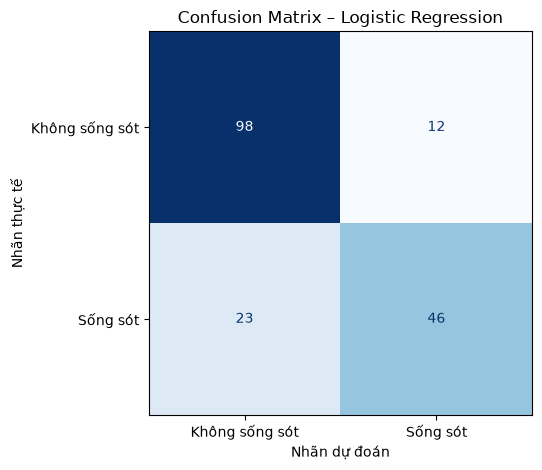

In [8]:
logistic_titanic_cm = confusion_matrix(
    y_test_titanic,
    titanic_logistic_prediction
)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_titanic_cm,
    display_labels=["Không sống sót", "Sống sót"]
).plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.tight_layout()
plt.show()

## Linear Regression – Titanic

Linear Regression dự đoán giá trị liên tục. Để dùng cho bài toán phân loại, đặt ngưỡng:

- Dự đoán `< 0.5` → lớp 0.
- Dự đoán `>= 0.5` → lớp 1.

Mô hình này chỉ được dùng để so sánh vì không phải thuật toán phù hợp nhất cho phân loại nhị phân.

In [9]:
titanic_linear_model = Pipeline([
    ("preprocessor", create_titanic_preprocessor()),
    ("model", LinearRegression())
])

titanic_linear_model.fit(
    X_train_titanic,
    y_train_titanic
)

titanic_linear_raw_prediction = titanic_linear_model.predict(
    X_test_titanic
)

titanic_linear_prediction = (
    titanic_linear_raw_prediction >= 0.5
).astype(int)

titanic_linear_metrics = calculate_metrics(
    "Linear Regression + threshold",
    y_test_titanic,
    titanic_linear_prediction,
    average="binary"
)

display(
    pd.DataFrame([titanic_linear_metrics]).set_index("Model")
)

print(
    classification_report(
        y_test_titanic,
        titanic_linear_prediction,
        target_names=["Không sống sót", "Sống sót"],
        zero_division=0
    )
)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Linear Regression + threshold,0.8101,0.7869,0.6957,0.7385


                precision    recall  f1-score   support

Không sống sót       0.82      0.88      0.85       110
      Sống sót       0.79      0.70      0.74        69

      accuracy                           0.81       179
     macro avg       0.80      0.79      0.79       179
  weighted avg       0.81      0.81      0.81       179



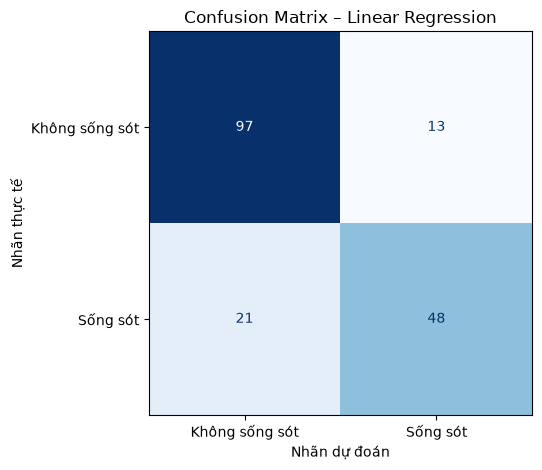

In [10]:
linear_titanic_cm = confusion_matrix(
    y_test_titanic,
    titanic_linear_prediction
)

ConfusionMatrixDisplay(
    confusion_matrix=linear_titanic_cm,
    display_labels=["Không sống sót", "Sống sót"]
).plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix – Linear Regression")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.tight_layout()
plt.show()

## So sánh hai mô hình Titanic

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244
Linear Regression + threshold,0.8101,0.7869,0.6957,0.7385


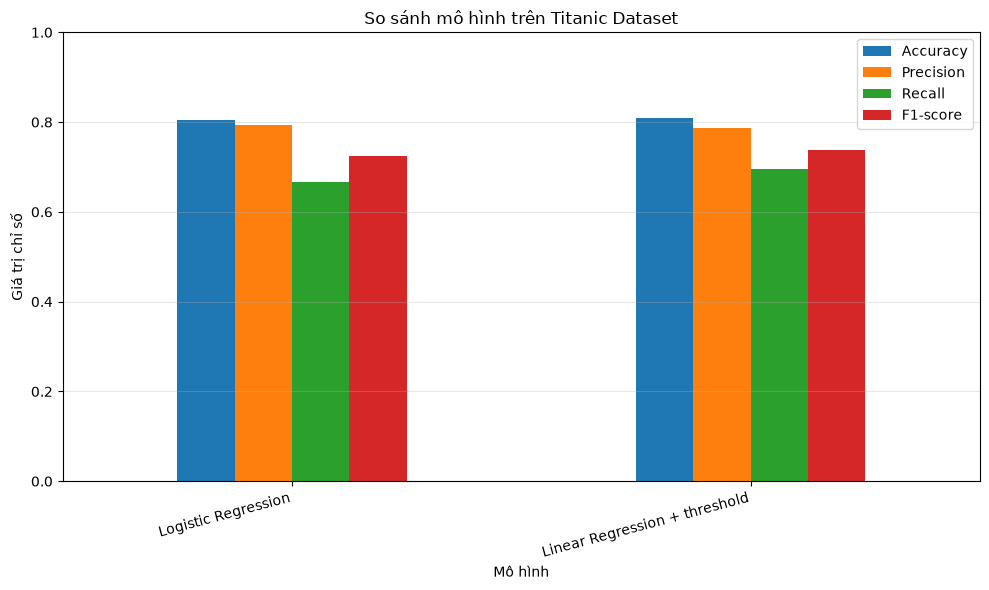

In [11]:
titanic_comparison = pd.DataFrame([
    titanic_logistic_metrics,
    titanic_linear_metrics
]).set_index("Model")

display(titanic_comparison)

titanic_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("So sánh mô hình trên Titanic Dataset")
plt.xlabel("Mô hình")
plt.ylabel("Giá trị chỉ số")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:

for model_name, row in titanic_comparison.iterrows():
    print(
        f"{model_name}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"Precision={row['Precision']:.4f}, "
        f"Recall={row['Recall']:.4f}, "
        f"F1={row['F1-score']:.4f}"
    )

print()
print(
    "Logistic Regression phù hợp hơn về bản chất vì Titanic là "
    "bài toán phân loại nhị phân. Logistic Regression mô hình hóa "
    "xác suất từ 0 đến 1, còn Linear Regression có thể tạo kết quả "
    "nhỏ hơn 0 hoặc lớn hơn 1 và phải dùng thêm ngưỡng 0.5."
)

Logistic Regression: Accuracy=0.8045, Precision=0.7931, Recall=0.6667, F1=0.7244
Linear Regression + threshold: Accuracy=0.8101, Precision=0.7869, Recall=0.6957, F1=0.7385

Logistic Regression phù hợp hơn về bản chất vì Titanic là bài toán phân loại nhị phân. Logistic Regression mô hình hóa xác suất từ 0 đến 1, còn Linear Regression có thể tạo kết quả nhỏ hơn 0 hoặc lớn hơn 1 và phải dùng thêm ngưỡng 0.5.


# BÀI 2 – DRY BEAN DATASET

Notebook ưu tiên đọc hai file đã preprocessing:

- `dry_bean_train.csv`
- `dry_bean_test.csv`

Nếu chưa có hai file trên, notebook sẽ tự đọc `Dry_Bean_Dataset.xlsx`, làm sạch, chia train/test và lưu hai file CSV.

In [13]:
candidate_directories = [
    Path("."),
    Path("/mnt/data"),
    Path("Dry_Bean_Dataset")
]

train_candidates = [
    directory / "dry_bean_train.csv"
    for directory in candidate_directories
]

test_candidates = [
    directory / "dry_bean_test.csv"
    for directory in candidate_directories
]

excel_candidates = [
    directory / "Dry_Bean_Dataset.xlsx"
    for directory in candidate_directories
]

TRAIN_PATH = next(
    (path for path in train_candidates if path.exists()),
    None
)

TEST_PATH = next(
    (path for path in test_candidates if path.exists()),
    None
)

EXCEL_PATH = next(
    (path for path in excel_candidates if path.exists()),
    None
)

if TRAIN_PATH is not None and TEST_PATH is not None:
    print("Đọc dữ liệu Dry Bean từ hai file CSV.")
    dry_bean_train_df = pd.read_csv(TRAIN_PATH)
    dry_bean_test_df = pd.read_csv(TEST_PATH)

elif EXCEL_PATH is not None:
    print("Chưa có CSV. Tiến hành preprocessing từ file Excel.")

    dry_bean_df = pd.read_excel(
        EXCEL_PATH,
        engine="openpyxl"
    )

    dry_bean_df.columns = dry_bean_df.columns.str.strip()

    target_candidates = [
        column
        for column in dry_bean_df.columns
        if column.lower() == "class"
    ]

    if not target_candidates:
        raise ValueError("Không tìm thấy cột Class.")

    target_column = target_candidates[0]
    feature_columns = [
        column
        for column in dry_bean_df.columns
        if column != target_column
    ]

    dry_bean_df[feature_columns] = dry_bean_df[
        feature_columns
    ].apply(pd.to_numeric, errors="coerce")

    dry_bean_df[target_column] = (
        dry_bean_df[target_column]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    print("Kích thước ban đầu:", dry_bean_df.shape)
    print("Missing:", dry_bean_df.isna().sum().sum())
    print("Duplicate:", dry_bean_df.duplicated().sum())

    dry_bean_df = (
        dry_bean_df
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    X_full = dry_bean_df.drop(columns=target_column)
    y_full = dry_bean_df[target_column]

    (
        X_train_bean,
        X_test_bean,
        y_train_bean,
        y_test_bean
    ) = train_test_split(
        X_full,
        y_full,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_full
    )

    dry_bean_train_df = X_train_bean.copy()
    dry_bean_train_df[target_column] = y_train_bean

    dry_bean_test_df = X_test_bean.copy()
    dry_bean_test_df[target_column] = y_test_bean

    output_directory = EXCEL_PATH.parent

    dry_bean_train_df.to_csv(
        output_directory / "dry_bean_train.csv",
        index=False
    )

    dry_bean_test_df.to_csv(
        output_directory / "dry_bean_test.csv",
        index=False
    )

else:
    raise FileNotFoundError(
        "Không tìm thấy dry_bean_train.csv, dry_bean_test.csv "
        "hoặc Dry_Bean_Dataset.xlsx."
    )

print("Train shape:", dry_bean_train_df.shape)
print("Test shape :", dry_bean_test_df.shape)

display(dry_bean_train_df.head())

Đọc dữ liệu Dry Bean từ hai file CSV.
Train shape: (10834, 17)
Test shape : (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.6380,399.1002,225.0058,1.7737,0.8259,71088,297.4109,0.7074,0.9773,0.7630,0.7452,0.0057,0.0011,0.5553,0.9850,CALI
1,82877,1162.5810,391.8170,270.8361,1.4467,0.7226,84171,324.8419,0.8260,0.9846,0.7705,0.8291,0.0047,0.0014,0.6873,0.9944,BARBUNYA
2,65042,1023.5060,419.2029,198.9628,2.1069,0.8802,65748,287.7743,0.7834,0.9893,0.7802,0.6865,0.0064,0.0009,0.4713,0.9929,HOROZ
3,41315,758.9200,287.4383,183.4476,1.5669,0.7699,41704,229.3554,0.7919,0.9907,0.9014,0.7979,0.0070,0.0017,0.6367,0.9976,SIRA
4,91088,1168.6450,459.3007,253.9505,1.8086,0.8332,91799,340.5537,0.7891,0.9923,0.8381,0.7415,0.0050,0.0009,0.5498,0.9943,CALI


In [14]:
target_candidates = [
    column
    for column in dry_bean_train_df.columns
    if column.lower() == "class"
]

if not target_candidates:
    raise ValueError("Không tìm thấy cột Class trong tập train.")

DRY_BEAN_TARGET = target_candidates[0]

X_train_bean = dry_bean_train_df.drop(
    columns=DRY_BEAN_TARGET
).copy()

y_train_bean = dry_bean_train_df[
    DRY_BEAN_TARGET
].astype(str).str.strip().str.upper()

X_test_bean = dry_bean_test_df.drop(
    columns=DRY_BEAN_TARGET
).copy()

y_test_bean = dry_bean_test_df[
    DRY_BEAN_TARGET
].astype(str).str.strip().str.upper()

dry_bean_class_names = sorted(
    y_train_bean.unique()
)

print("X_train:", X_train_bean.shape)
print("X_test :", X_test_bean.shape)
print("Các lớp:", dry_bean_class_names)

X_train: (10834, 16)
X_test : (2709, 16)
Các lớp: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


,Train count,Test count
class,,
BARBUNYA,1057,265
BOMBAY,418,104
CALI,1304,326
DERMASON,2837,709
HOROZ,1488,372
SEKER,1621,406
SIRA,2109,527


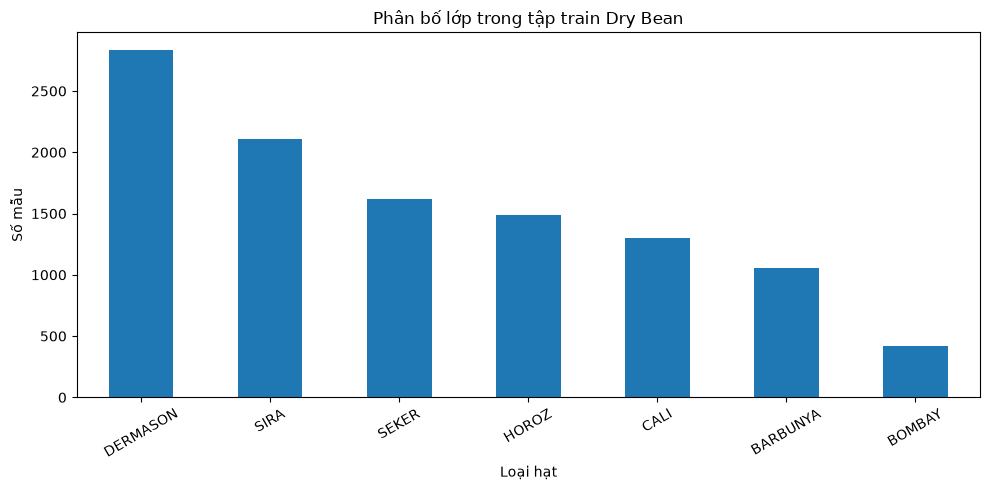

In [15]:
class_distribution = pd.DataFrame({
    "Train count": y_train_bean.value_counts().sort_index(),
    "Test count": y_test_bean.value_counts().sort_index()
}).fillna(0).astype(int)

display(class_distribution)

plt.figure(figsize=(10, 5))
y_train_bean.value_counts().sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Phân bố lớp trong tập train Dry Bean")
plt.xlabel("Loại hạt")
plt.ylabel("Số mẫu")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Logistic Regression – Dry Bean

`StandardScaler` được đặt trong Pipeline để scaler chỉ học thông tin từ tập train.

In [16]:
dry_bean_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

dry_bean_logistic_model.fit(
    X_train_bean,
    y_train_bean
)

dry_bean_logistic_prediction = (
    dry_bean_logistic_model.predict(
        X_test_bean
    )
)

dry_bean_logistic_metrics = calculate_metrics(
    "Logistic Regression",
    y_test_bean,
    dry_bean_logistic_prediction,
    average="macro"
)

display(
    pd.DataFrame([dry_bean_logistic_metrics]).set_index("Model")
)

print(
    classification_report(
        y_test_bean,
        dry_bean_logistic_prediction,
        labels=dry_bean_class_names,
        zero_division=0
    )
)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.9192,0.9307,0.9300,0.9302


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



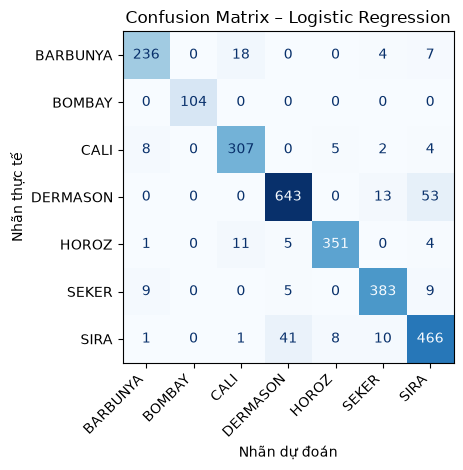

In [17]:
dry_bean_logistic_cm = confusion_matrix(
    y_test_bean,
    dry_bean_logistic_prediction,
    labels=dry_bean_class_names
)

ConfusionMatrixDisplay(
    confusion_matrix=dry_bean_logistic_cm,
    display_labels=dry_bean_class_names
).plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## K-Nearest Neighbors – KNN

`GridSearchCV` được dùng để chọn:

- `n_neighbors`: số láng giềng.
- `weights`: cách gán trọng số.
- `p`: Manhattan (`p=1`) hoặc Euclidean (`p=2`).

Tập test không tham gia lựa chọn tham số.

In [18]:
dry_bean_knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_parameter_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

dry_bean_knn_search = GridSearchCV(
    estimator=dry_bean_knn_pipeline,
    param_grid=knn_parameter_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

dry_bean_knn_search.fit(
    X_train_bean,
    y_train_bean
)

print("Best params:", dry_bean_knn_search.best_params_)
print(
    "Best cross-validation Macro F1:",
    round(dry_bean_knn_search.best_score_, 4)
)

Best params: {'model__n_neighbors': 13, 'model__p': 2, 'model__weights': 'distance'}
Best cross-validation Macro F1: 0.9385


In [19]:
knn_search_results = pd.DataFrame(
    dry_bean_knn_search.cv_results_
)

knn_summary = knn_search_results[[
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__p",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

knn_summary.columns = [
    "k",
    "weights",
    "p",
    "Mean validation F1",
    "Validation F1 std",
    "Rank"
]

display(knn_summary.head(15))

,k,weights,p,Mean validation F1,Validation F1 std,Rank
23,13,distance,2,0.9385,0.0030,1
27,15,distance,2,0.9382,0.0016,2
22,13,uniform,2,0.9376,0.0021,3
26,15,uniform,2,0.9372,0.0018,4
9,7,distance,1,0.9367,0.0026,5
19,11,distance,2,0.9366,0.0022,6
15,9,distance,2,0.9362,0.0025,7
11,7,distance,2,0.9362,0.0026,8
25,15,distance,1,0.9361,0.0016,9
8,7,uniform,1,0.9360,0.0034,10


In [20]:
dry_bean_knn_model = (
    dry_bean_knn_search.best_estimator_
)

dry_bean_knn_prediction = (
    dry_bean_knn_model.predict(
        X_test_bean
    )
)

best_params = dry_bean_knn_search.best_params_

dry_bean_knn_name = (
    f"KNN (k={best_params['model__n_neighbors']}, "
    f"weights={best_params['model__weights']}, "
    f"p={best_params['model__p']})"
)

dry_bean_knn_metrics = calculate_metrics(
    dry_bean_knn_name,
    y_test_bean,
    dry_bean_knn_prediction,
    average="macro"
)

display(
    pd.DataFrame([dry_bean_knn_metrics]).set_index("Model")
)

print(
    classification_report(
        y_test_bean,
        dry_bean_knn_prediction,
        labels=dry_bean_class_names,
        zero_division=0
    )
)

,Accuracy,Precision,Recall,F1-score
Model,,,,
"KNN (k=13, weights=distance, p=2)",0.9158,0.9308,0.9266,0.9283


              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.94      0.94      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



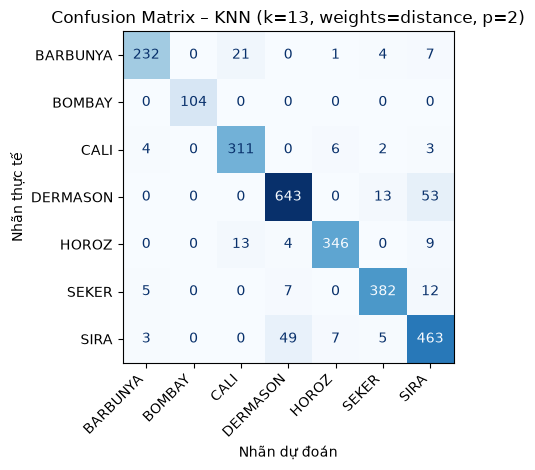

In [21]:
dry_bean_knn_cm = confusion_matrix(
    y_test_bean,
    dry_bean_knn_prediction,
    labels=dry_bean_class_names
)

ConfusionMatrixDisplay(
    confusion_matrix=dry_bean_knn_cm,
    display_labels=dry_bean_class_names
).plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(f"Confusion Matrix – {dry_bean_knn_name}")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## So sánh Logistic Regression và KNN

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.9192,0.9307,0.9300,0.9302
"KNN (k=13, weights=distance, p=2)",0.9158,0.9308,0.9266,0.9283


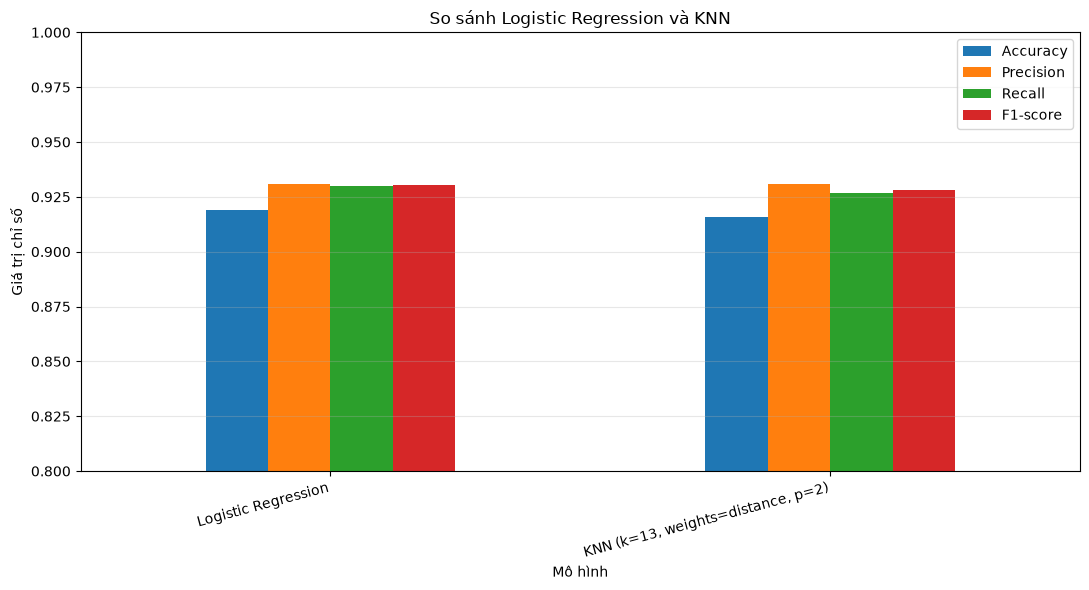

In [22]:
dry_bean_comparison = pd.DataFrame([
    dry_bean_logistic_metrics,
    dry_bean_knn_metrics
]).set_index("Model")

display(dry_bean_comparison)

dry_bean_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("So sánh Logistic Regression và KNN")
plt.xlabel("Mô hình")
plt.ylabel("Giá trị chỉ số")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
def get_confused_class_pairs(cm, labels, top_n=10):
    error_records = []

    for actual_index, actual_class in enumerate(labels):
        for predicted_index, predicted_class in enumerate(labels):
            error_count = cm[actual_index, predicted_index]

            if actual_index != predicted_index and error_count > 0:
                error_records.append({
                    "Lớp thực tế": actual_class,
                    "Lớp dự đoán": predicted_class,
                    "Số lần nhầm": int(error_count)
                })

    error_df = pd.DataFrame(error_records)

    if error_df.empty:
        return error_df

    return (
        error_df
        .sort_values("Số lần nhầm", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

print("LỖI PHỔ BIẾN – LOGISTIC REGRESSION")
display(
    get_confused_class_pairs(
        dry_bean_logistic_cm,
        dry_bean_class_names
    )
)

print("\nLỖI PHỔ BIẾN – KNN")
display(
    get_confused_class_pairs(
        dry_bean_knn_cm,
        dry_bean_class_names
    )
)

LỖI PHỔ BIẾN – LOGISTIC REGRESSION


,Lớp thực tế,Lớp dự đoán,Số lần nhầm
0,DERMASON,SIRA,53
1,SIRA,DERMASON,41
2,BARBUNYA,CALI,18
3,DERMASON,SEKER,13
4,HOROZ,CALI,11
5,SIRA,SEKER,10
6,SEKER,BARBUNYA,9
7,SEKER,SIRA,9
8,CALI,BARBUNYA,8
9,SIRA,HOROZ,8



LỖI PHỔ BIẾN – KNN


,Lớp thực tế,Lớp dự đoán,Số lần nhầm
0,DERMASON,SIRA,53
1,SIRA,DERMASON,49
2,BARBUNYA,CALI,21
3,HOROZ,CALI,13
4,DERMASON,SEKER,13
5,SEKER,SIRA,12
6,HOROZ,SIRA,9
7,BARBUNYA,SIRA,7
8,SEKER,DERMASON,7
9,SIRA,HOROZ,7


In [24]:
dry_bean_predictions = (
    X_test_bean
    .reset_index(drop=True)
    .copy()
)

dry_bean_predictions["Actual class"] = (
    y_test_bean.reset_index(drop=True)
)

dry_bean_predictions["Logistic prediction"] = (
    dry_bean_logistic_prediction
)

dry_bean_predictions["KNN prediction"] = (
    dry_bean_knn_prediction
)

dry_bean_predictions["Logistic correct"] = (
    dry_bean_predictions["Actual class"]
    == dry_bean_predictions["Logistic prediction"]
)

dry_bean_predictions["KNN correct"] = (
    dry_bean_predictions["Actual class"]
    == dry_bean_predictions["KNN prediction"]
)

dry_bean_predictions.to_csv(
    "dry_bean_test_predictions.csv",
    index=False
)

dry_bean_comparison.to_csv(
    "dry_bean_model_comparison.csv"
)

display(dry_bean_predictions.head(10))

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,Actual class,Logistic prediction,KNN prediction,Logistic correct,KNN correct
0,40512,737.6360,248.2020,208.5252,1.1903,0.5424,40973,227.1156,0.7443,0.9887,0.9356,0.9150,0.0061,0.0026,0.8373,0.9966,SEKER,SEKER,SEKER,True,True
1,31890,660.6550,250.4173,162.5225,1.5408,0.7608,32240,201.5034,0.8020,0.9891,0.9182,0.8047,0.0079,0.0020,0.6475,0.9977,DERMASON,DERMASON,DERMASON,True,True
2,33107,671.8690,244.7283,172.9381,1.4151,0.7076,33506,205.3123,0.7987,0.9881,0.9216,0.8389,0.0074,0.0023,0.7038,0.9960,DERMASON,DERMASON,DERMASON,True,True
3,61684,984.8780,412.1156,191.4733,2.1523,0.8855,62303,280.2472,0.7847,0.9901,0.7991,0.6800,0.0067,0.0009,0.4624,0.9953,HOROZ,HOROZ,HOROZ,True,True
4,37189,700.2530,243.3434,194.9101,1.2485,0.5987,37534,217.6017,0.7848,0.9908,0.9530,0.8942,0.0065,0.0026,0.7996,0.9983,SEKER,SEKER,SEKER,True,True
5,38811,726.3950,268.1523,184.9021,1.4502,0.7242,39206,222.2964,0.7917,0.9899,0.9243,0.8290,0.0069,0.0020,0.6872,0.9966,DERMASON,DERMASON,DERMASON,True,True
6,35072,693.4530,254.3637,176.2521,1.4432,0.7210,35397,211.3174,0.8022,0.9908,0.9165,0.8308,0.0073,0.0021,0.6902,0.9961,DERMASON,DERMASON,DERMASON,True,True
7,27680,608.7360,224.3339,157.2893,1.4262,0.7130,27937,187.7319,0.7533,0.9908,0.9387,0.8368,0.0081,0.0025,0.7003,0.9988,DERMASON,DERMASON,DERMASON,True,True
8,68770,1032.4960,353.7829,248.6159,1.4230,0.7115,69908,295.9065,0.7551,0.9837,0.8106,0.8364,0.0051,0.0016,0.6996,0.9955,BARBUNYA,BARBUNYA,BARBUNYA,True,True
9,31878,667.7180,254.7043,159.7105,1.5948,0.7790,32212,201.4655,0.7578,0.9896,0.8985,0.7910,0.0080,0.0019,0.6256,0.9978,DERMASON,DERMASON,DERMASON,True,True


In [25]:

for model_name, row in dry_bean_comparison.iterrows():
    print(
        f"{model_name}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"Precision={row['Precision']:.4f}, "
        f"Recall={row['Recall']:.4f}, "
        f"F1={row['F1-score']:.4f}"
    )

best_model = dry_bean_comparison["F1-score"].idxmax()

print()
print(
    "Mô hình có Macro F1-score cao nhất:",
    best_model
)

print(
    "Logistic Regression có ưu điểm là mô hình gọn và dự đoán nhanh. "
    "KNN trực quan nhưng phải lưu dữ liệu train và tính khoảng cách "
    "khi dự đoán."
)

Logistic Regression: Accuracy=0.9192, Precision=0.9307, Recall=0.9300, F1=0.9302
KNN (k=13, weights=distance, p=2): Accuracy=0.9158, Precision=0.9308, Recall=0.9266, F1=0.9283

Mô hình có Macro F1-score cao nhất: Logistic Regression
Logistic Regression có ưu điểm là mô hình gọn và dự đoán nhanh. KNN trực quan nhưng phải lưu dữ liệu train và tính khoảng cách khi dự đoán.
